# Music Emotion Classification — Hybrid Pipeline

Classifies songs into **CALM**, **ENERGY**, or **OTHER** using a hybrid approach:
1. **Rule-based pre-filtering** — removes live recordings and speech-only tracks
2. **Weighted arousal scoring** — computes a per-track arousal score from audio features
3. **Threshold classification** — assigns classes based on arousal score + valence guard
4. **Unsupervised validation** — K-Means / GMM as independent sanity check

**Why hybrid?** The class definitions are domain-driven (BPM thresholds, "not sad", no live tracks).
These constraints are not discoverable from data alone. Encoding them as explicit rules is more
explainable than hoping a clustering algorithm recovers them.

---

### Retraining Checklist
- [ ] Set `PARTICIPANT` variable below
- [ ] Run all cells top-to-bottom
- [ ] Check class distribution printout (Phase 4)
- [ ] Spot-check 10 songs per class (Phase 6)
- [ ] Review saved outputs in `data/playlists/{participant}/playlist_ml/`

---
## Phase 1 — Data Ingestion & Validation
**Goal:** Load participant data, check quality, produce a clean DataFrame.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Imports loaded OK")

Imports loaded OK


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — Change these settings per participant / run
# ══════════════════════════════════════════════════════════════════════════════

# Which participant to classify (folder name under data/playlists/)
# Set to "all" to load every participant's combined.csv
PARTICIPANT = "peer"

# Project root (auto-detected from notebook location)
PROJECT_ROOT = Path("..").resolve()

# ── Feature selection ────────────────────────────────────────────────────────
# 8 features used for arousal scoring and clustering
SCORING_FEATURES = [
    "tempo",            # BPM — primary class separator
    "energy",           # intensity/activity (0-1)
    "loudness",         # volume in dB (-60 to 0)
    "valence",          # musical positivity (0-1), used as "not sad" guard
    "danceability",     # rhythm regularity (0-1)
    "acousticness",     # acoustic vs electronic (0-1)
    "instrumentalness", # vocal absence (0-1)
    "speechiness",      # spoken word content (0-1)
]

# ── Pre-filter thresholds (Spotify docs) ─────────────────────────────────────
# Tracks above these thresholds are excluded BEFORE classification
SPEECHINESS_THRESHOLD = 0.66   # >0.66 = spoken word / podcast
LIVENESS_THRESHOLD = 0.80      # >0.80 = high confidence live recording

# ── Arousal score weights ────────────────────────────────────────────────────
# Each weight reflects how much the feature contributes to perceived arousal.
# Positive = increases arousal, negative = decreases arousal.
AROUSAL_WEIGHTS = {
    "energy":       0.35,   # strongest arousal predictor (PCA + domain knowledge)
    "tempo":        0.30,   # directly tied to BPM class definitions
    "loudness":     0.20,   # louder = more energetic
    "acousticness": -0.10,  # acoustic = calmer (inverse relationship)
    "danceability": 0.05,   # slight boost for rhythmic tracks
}

# ── Classification thresholds ────────────────────────────────────────────────
CALM_THRESHOLD = 0.35      # arousal score below this → candidate for CALM
ENERGY_THRESHOLD = 0.65    # arousal score above this → ENERGY
VALENCE_FLOOR = 0.25       # CALM tracks must have valence >= this (excludes sad music)

print(f"Configuration loaded — participant: {PARTICIPANT}")

Configuration loaded — participant: peer


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
# Supports two modes:
#   - Single participant: loads data/playlists/{PARTICIPANT}/playlists_generated/combined.csv
#   - All participants:   globs every combined.csv and merges them

def load_participant_data(participant, project_root):
    """Load combined.csv for one or all participants."""
    playlists_dir = project_root / "data" / "playlists"

    if participant.lower() == "all":
        # Multi-participant mode: find all combined.csv files
        csv_files = sorted(playlists_dir.glob("*/playlists_generated/combined.csv"))
        if not csv_files:
            raise FileNotFoundError(f"No combined.csv found under {playlists_dir}")
        frames = []
        for f in csv_files:
            part_name = f.parent.parent.name
            part_df = pd.read_csv(f)
            part_df["participant"] = part_name
            frames.append(part_df)
            print(f"  Loaded {part_name}: {len(part_df)} songs")
        df = pd.concat(frames, ignore_index=True)
    else:
        # Single participant mode
        csv_path = playlists_dir / participant / "playlists_generated" / "combined.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"File not found: {csv_path}")
        df = pd.read_csv(csv_path)
        df["participant"] = participant

    return df


df_raw = load_participant_data(PARTICIPANT, PROJECT_ROOT)
print(f"\nLoaded: {len(df_raw)} songs, {df_raw['participant'].nunique()} participant(s)")
print(f"Columns ({len(df_raw.columns)}): {list(df_raw.columns)}")


Loaded: 691 songs, 1 participant(s)
Columns (25): ['Added At', 'Added By', 'Explicit', 'Genres', 'Popularity', 'Record Label', 'Release Date', 'acousticness', 'album', 'artists', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'speechiness', 'tempo', 'time_signature', 'uri', 'valence', 'participant']


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  VALIDATE DATA QUALITY
# ══════════════════════════════════════════════════════════════════════════════

# 1. Check that all required audio features are present
required_features = SCORING_FEATURES + ["liveness"]  # liveness needed for pre-filter
missing_cols = [f for f in required_features if f not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")
print("✓ All required features present")

# 2. Duplicates (by uri if available, else by name + artists)
if "uri" in df_raw.columns:
    n_dupes = df_raw.duplicated(subset=["uri"], keep="first").sum()
    df = df_raw.drop_duplicates(subset=["uri"], keep="first").copy()
else:
    n_dupes = df_raw.duplicated(subset=["name", "artists"], keep="first").sum()
    df = df_raw.drop_duplicates(subset=["name", "artists"], keep="first").copy()
print(f"✓ Removed {n_dupes} duplicate(s) → {len(df)} unique songs")

# 3. Missing values in scoring features
missing_report = df[SCORING_FEATURES + ["liveness"]].isnull().sum()
missing_any = missing_report[missing_report > 0]
if len(missing_any) > 0:
    print(f"\n  Missing values per feature:")
    for col, count in missing_any.items():
        print(f"    {col}: {count} ({count/len(df)*100:.1f}%)")
    n_before = len(df)
    df = df.dropna(subset=SCORING_FEATURES + ["liveness"])
    print(f"  Dropped {n_before - len(df)} rows with NaN → {len(df)} songs remaining")
else:
    print("✓ No missing values in scoring features")

# 4. Basic statistics
print(f"\n{'─'*60}")
print("Feature summary statistics:")
print(f"{'─'*60}")
display(df[SCORING_FEATURES + ["liveness"]].describe().round(3))

✓ All required features present
✓ Removed 0 duplicate(s) → 691 unique songs
✓ No missing values in scoring features

────────────────────────────────────────────────────────────
Feature summary statistics:
────────────────────────────────────────────────────────────


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,liveness
count,691.000,691.000,691.000,691.000,691.000,691.000,691.000,691.000,691.000
mean,119.845,0.558,-8.450,0.395,0.539,0.386,0.097,0.055,0.155
std,28.046,0.242,4.210,0.236,0.162,0.346,0.244,0.053,0.108
min,51.905,0.009,-27.011,0.029,0.065,0.000,0.000,0.024,0.033
25%,99.956,0.366,-10.432,0.202,0.444,0.041,0.000,0.032,0.095
50%,119.974,0.584,-7.379,0.373,0.554,0.292,0.000,0.038,0.112
75%,135.954,0.758,-5.605,0.540,0.668,0.716,0.007,0.054,0.172
max,207.821,0.983,-2.189,0.973,0.927,0.994,0.967,0.514,0.792


---
## Phase 2 — Preprocessing & Feature Selection
**Goal:** Pre-filter unsuitable tracks, select scoring features, normalize to [0, 1].

### Feature decisions
| Feature | Role | Reason |
|---------|------|--------|
| `tempo` | **Primary scorer** | Directly maps to BPM class definitions |
| `energy` | **Primary scorer** | Core arousal dimension |
| `loudness` | Scorer | "Not too loud" constraint for CALM |
| `valence` | Guard | "Not sad" constraint for CALM |
| `danceability` | Scorer | Proxy for rhythm steadiness |
| `acousticness` | Scorer | Inverse arousal indicator |
| `instrumentalness` | Scorer | Helps OTHER boundary |
| `speechiness` | **Pre-filter** | >0.66 = spoken word → excluded |
| `liveness` | **Pre-filter** | >0.80 = live recording → excluded |
| `duration_ms` | Dropped | No arousal relationship |
| `key` | Dropped | Categorical, no ordinal meaning |
| `mode` | Dropped | Too coarse (major/minor only) |
| `time_signature` | Dropped | Near-constant (most = 4/4) |

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  PRE-FILTER: Remove live recordings and speech-only tracks
# ══════════════════════════════════════════════════════════════════════════════
# These tracks violate the class definitions for both CALM and ENERGY:
#   "no live records or tracks with only speech and no music"
#
# Thresholds come from Spotify's official audio feature documentation:
#   speechiness > 0.66 → "tracks that are probably made entirely of spoken words"
#   liveness > 0.80    → "strong likelihood that the track was performed live"

n_before = len(df)

# Flag and remove speech-only tracks
speech_mask = df["speechiness"] > SPEECHINESS_THRESHOLD
n_speech = speech_mask.sum()
print(f"Speech-only tracks (speechiness > {SPEECHINESS_THRESHOLD}): {n_speech}")
if n_speech > 0 and n_speech <= 20:
    display(df.loc[speech_mask, ["name", "artists", "speechiness"]].head(10))

# Flag and remove live recordings
live_mask = df["liveness"] > LIVENESS_THRESHOLD
n_live = live_mask.sum()
print(f"Live recordings (liveness > {LIVENESS_THRESHOLD}): {n_live}")
if n_live > 0 and n_live <= 20:
    display(df.loc[live_mask, ["name", "artists", "liveness"]].head(10))

# Apply both filters
df = df[~speech_mask & ~live_mask].copy()
n_removed = n_before - len(df)
print(f"\n✓ Removed {n_removed} tracks ({n_speech} speech + {n_live} live, minus overlap)")
print(f"  Remaining: {len(df)} songs")

Speech-only tracks (speechiness > 0.66): 0
Live recordings (liveness > 0.8): 0

✓ Removed 0 tracks (0 speech + 0 live, minus overlap)
  Remaining: 691 songs


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  NORMALIZE FEATURES with MinMaxScaler [0, 1]
# ══════════════════════════════════════════════════════════════════════════════
# Why MinMaxScaler instead of StandardScaler?
#   - Every normalized feature becomes "percentage of its range" → easy to explain
#   - Arousal weights then directly say "35% of energy's full range contributes"
#   - No negative values to confuse interpretation

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[SCORING_FEATURES])

# Store as a DataFrame for readability
df_scaled = pd.DataFrame(X_scaled, columns=SCORING_FEATURES, index=df.index)

print("✓ Features normalized to [0, 1] with MinMaxScaler")
print(f"  Shape: {df_scaled.shape}")
display(df_scaled.describe().round(3))

✓ Features normalized to [0, 1] with MinMaxScaler
  Shape: (691, 8)


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness
count,691.000,691.000,691.000,691.000,691.000,691.000,691.000,691.000
mean,0.436,0.563,0.748,0.387,0.550,0.388,0.100,0.064
std,0.180,0.248,0.170,0.250,0.188,0.348,0.252,0.109
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.308,0.367,0.668,0.184,0.440,0.041,0.000,0.017
50%,0.437,0.590,0.791,0.364,0.567,0.294,0.000,0.029
75%,0.539,0.768,0.862,0.541,0.699,0.721,0.008,0.062
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


---
## Phase 3 — Exploratory Analysis
**Goal:** Visualize feature distributions and validate that CALM / ENERGY are separable.

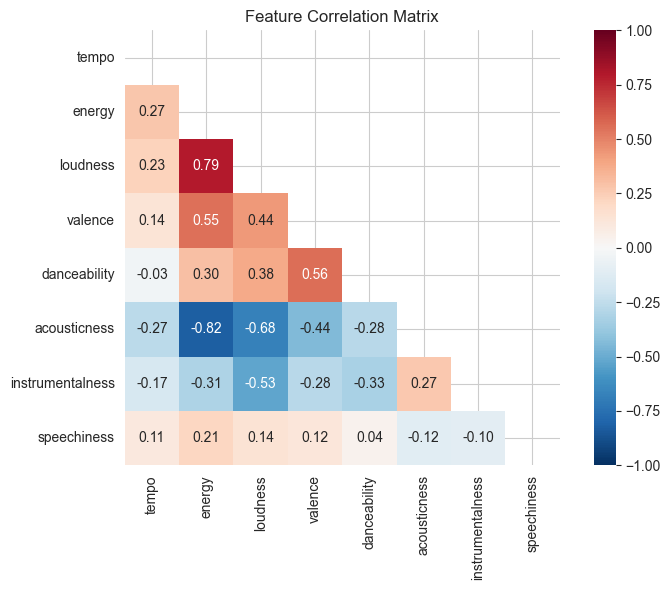


Highly correlated pairs (|r| > 0.7):
  energy ↔ loudness: r = 0.79
  energy ↔ acousticness: r = -0.82


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  3a. CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════════════════════
# Check for redundant features. Expected: energy ↔ loudness (strong positive),
# energy ↔ acousticness (strong negative).

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[SCORING_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7)
print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr.index[i]} ↔ {corr.columns[j]}: r = {r:.2f}")

PCA explained variance: PC1=54.3%, PC2=15.0%, total=69.3%

PCA Loadings (how each feature contributes to each component):


,PC1,PC2
tempo,-0.119,0.071
energy,-0.476,0.166
loudness,-0.294,-0.073
valence,-0.351,-0.349
danceability,-0.186,-0.378
acousticness,0.670,-0.456
instrumentalness,0.255,0.700
speechiness,-0.041,-0.009


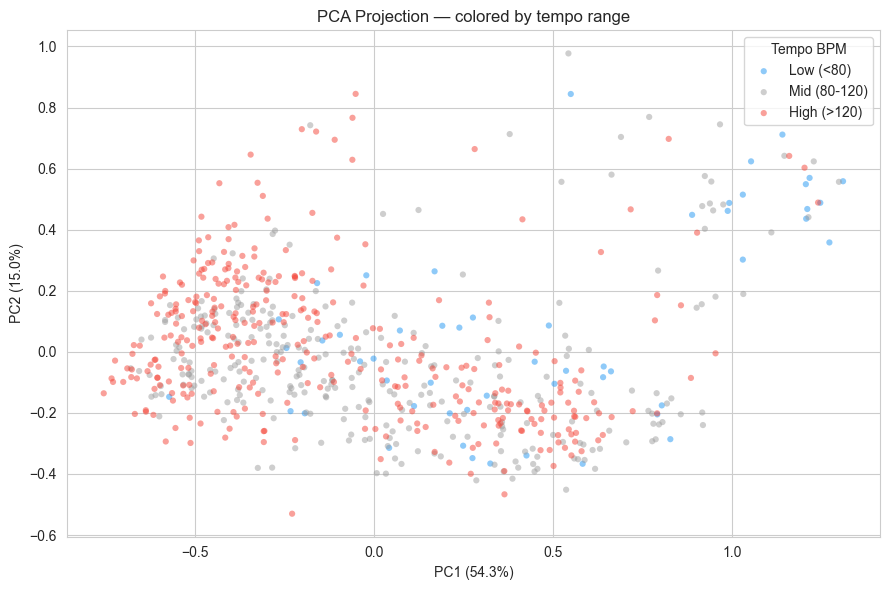

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  3b. PCA — 2-component projection
# ══════════════════════════════════════════════════════════════════════════════
# Reduce to 2D to eyeball whether calm/energy regions are spatially separable.
# Color by tempo bins (low/mid/high) as a proxy before classification.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%, "
      f"total={sum(explained)*100:.1f}%")

# Loadings — which features drive each component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=SCORING_FEATURES,
)
print("\nPCA Loadings (how each feature contributes to each component):")
display(loadings.round(3))

# Scatter plot colored by tempo bins
tempo_bins = pd.cut(df["tempo"], bins=[0, 80, 120, 300], labels=["Low (<80)", "Mid (80-120)", "High (>120)"])
colors_map = {"Low (<80)": "#2196F3", "Mid (80-120)": "#9E9E9E", "High (>120)": "#F44336"}

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in colors_map.items():
    mask = tempo_bins == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
               alpha=0.5, s=20, edgecolors="none")

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_title("PCA Projection — colored by tempo range")
ax.legend(title="Tempo BPM")
plt.tight_layout()
plt.show()

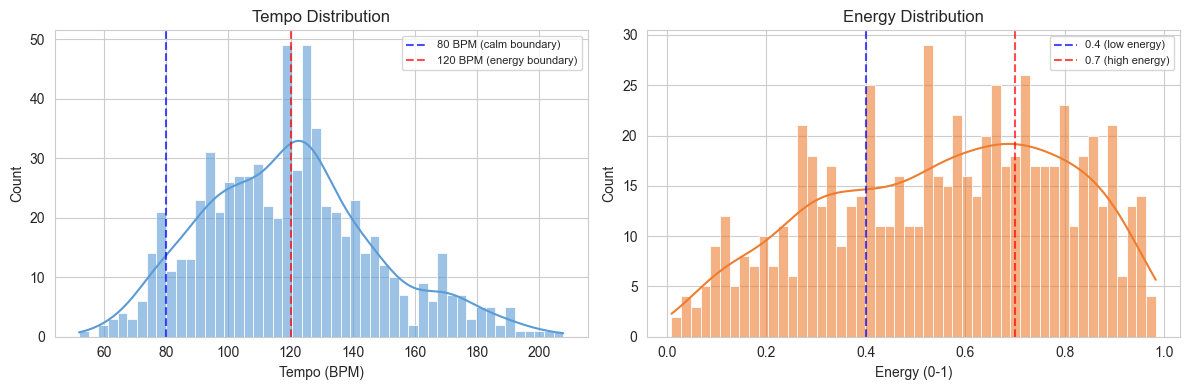

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  3c. DISTRIBUTION PLOTS — Tempo & Energy KDEs
# ══════════════════════════════════════════════════════════════════════════════
# Look for natural modes (peaks) that might align with calm vs energy regions.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tempo distribution
sns.histplot(df["tempo"], kde=True, bins=50, color="#5b9bd5", ax=axes[0], alpha=0.6)
axes[0].axvline(80, color="blue", linestyle="--", alpha=0.7, label="80 BPM (calm boundary)")
axes[0].axvline(120, color="red", linestyle="--", alpha=0.7, label="120 BPM (energy boundary)")
axes[0].set_title("Tempo Distribution")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].legend(fontsize=8)

# Energy distribution
sns.histplot(df["energy"], kde=True, bins=50, color="#ed7d31", ax=axes[1], alpha=0.6)
axes[1].axvline(0.4, color="blue", linestyle="--", alpha=0.7, label="0.4 (low energy)")
axes[1].axvline(0.7, color="red", linestyle="--", alpha=0.7, label="0.7 (high energy)")
axes[1].set_title("Energy Distribution")
axes[1].set_xlabel("Energy (0-1)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

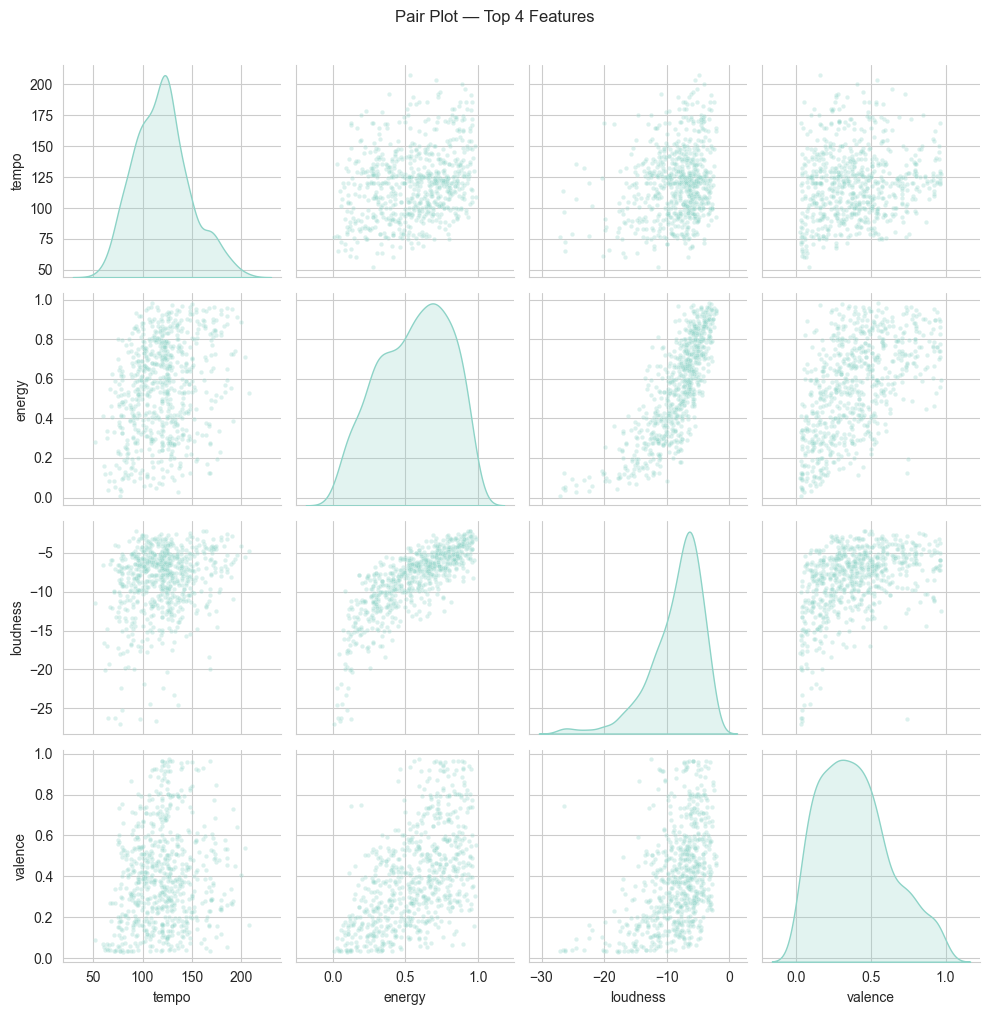

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  3d. PAIR PLOT — Top 4 features
# ══════════════════════════════════════════════════════════════════════════════
# Quick visual check of how the 4 most important features relate pairwise.

pair_features = ["tempo", "energy", "loudness", "valence"]
g = sns.pairplot(df[pair_features], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10},
                 diag_kws={"fill": True})
g.figure.suptitle("Pair Plot — Top 4 Features", y=1.01)
plt.tight_layout()
plt.show()

---
## Phase 4 — Labelling Strategy (Arousal Score + Thresholds)
**Goal:** Assign each track CALM / ENERGY / OTHER using an explainable, deterministic scoring approach.

### Why not pure K-Means?
K-Means with k=3 gives 3 groups, but there is no guarantee they align with our domain-defined classes.
The class definitions include constraints (BPM thresholds, "not sad", no live tracks) that clustering
cannot encode. A weighted arousal score is more transparent and directly maps to the research rationale.

### Arousal score formula (on MinMax-scaled [0,1] features):
```
arousal = 0.35 × energy + 0.30 × tempo + 0.20 × loudness − 0.10 × acousticness + 0.05 × danceability
```

### Classification rules:
- `arousal < 0.35` AND `valence >= 0.25` → **CALM**
- `arousal > 0.65` → **ENERGY**
- Everything else → **OTHER**

Arousal score range: [-0.046, 0.812]
Mean: 0.466, Median: 0.486
Std:  0.172


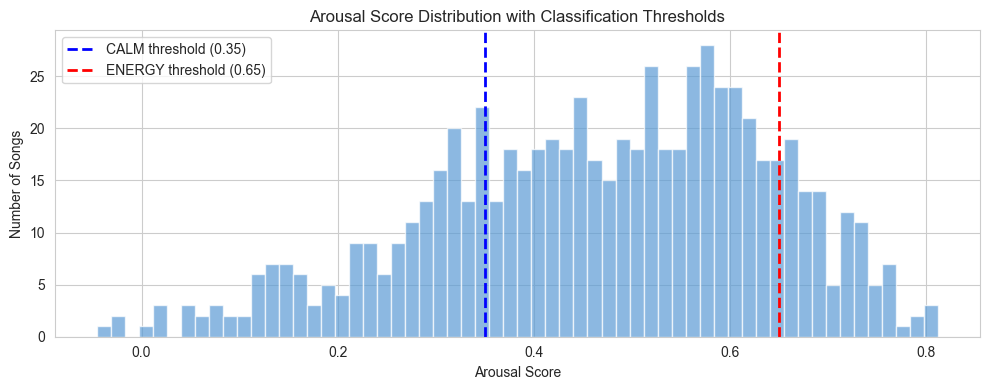

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  4a. COMPUTE PER-TRACK AROUSAL SCORE
# ══════════════════════════════════════════════════════════════════════════════
# The arousal score is a weighted sum of normalized features.
# Higher score = more energetic / arousing.
# Each weight reflects how much the feature contributes to perceived arousal:
#   energy (0.35)      — strongest predictor (confirmed by PCA + domain knowledge)
#   tempo (0.30)       — directly tied to BPM class definitions
#   loudness (0.20)    — louder tracks feel more intense
#   acousticness(-0.10)— acoustic instruments signal calmer music
#   danceability(0.05) — slight boost for rhythmic, steady tracks

# Compute arousal as weighted sum of normalized features
df["arousal_score"] = sum(
    weight * df_scaled[feature]
    for feature, weight in AROUSAL_WEIGHTS.items()
)

# Show distribution
print(f"Arousal score range: [{df['arousal_score'].min():.3f}, {df['arousal_score'].max():.3f}]")
print(f"Mean: {df['arousal_score'].mean():.3f}, Median: {df['arousal_score'].median():.3f}")
print(f"Std:  {df['arousal_score'].std():.3f}")

# Histogram with threshold lines
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["arousal_score"], bins=60, color="#5b9bd5", alpha=0.7, edgecolor="white")
ax.axvline(CALM_THRESHOLD, color="blue", linestyle="--", linewidth=2,
           label=f"CALM threshold ({CALM_THRESHOLD})")
ax.axvline(ENERGY_THRESHOLD, color="red", linestyle="--", linewidth=2,
           label=f"ENERGY threshold ({ENERGY_THRESHOLD})")
ax.set_xlabel("Arousal Score")
ax.set_ylabel("Number of Songs")
ax.set_title("Arousal Score Distribution with Classification Thresholds")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  4b. CLASSIFY TRACKS
# ══════════════════════════════════════════════════════════════════════════════
# Apply threshold-based classification with valence guard for CALM.
#
# Rules:
#   CALM   — low arousal AND not sad (valence >= floor)
#   ENERGY — high arousal (no valence constraint — energetic sad music is rare)
#   OTHER  — everything in between, or low-arousal but too sad for CALM

def classify_track(arousal, valence_norm):
    """Classify a single track based on its arousal score and normalized valence.

    Returns one of: 'calm', 'energy', 'other'
    """
    if arousal < CALM_THRESHOLD and valence_norm >= VALENCE_FLOOR:
        return "calm"
    elif arousal > ENERGY_THRESHOLD:
        return "energy"
    else:
        return "other"


# Apply classification to every track
df["class"] = [
    classify_track(arousal, valence)
    for arousal, valence in zip(df["arousal_score"], df_scaled["valence"])
]

# ── Report class distribution ────────────────────────────────────────────────
print("Class distribution:")
class_counts = df["class"].value_counts()
for cls in ["calm", "energy", "other"]:
    n = class_counts.get(cls, 0)
    pct = n / len(df) * 100
    print(f"  {cls.upper():>6}: {n:>5} songs ({pct:.1f}%)")

# Warn if any class is too small
for cls in ["calm", "energy"]:
    n = class_counts.get(cls, 0)
    if n / len(df) < 0.05:
        print(f"\n⚠ WARNING: {cls.upper()} has fewer than 5% of tracks — consider adjusting thresholds")

Class distribution:
    CALM:    53 songs (7.7%)
  ENERGY:    96 songs (13.9%)
   OTHER:   542 songs (78.4%)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  4c. MEAN FEATURES PER CLASS — interpretability check
# ══════════════════════════════════════════════════════════════════════════════
# This table should confirm that:
#   CALM  → low tempo, low energy, high acousticness, moderate valence
#   ENERGY → high tempo, high energy, high loudness, low acousticness

class_means = df.groupby("class")[SCORING_FEATURES + ["arousal_score"]].mean().round(3)
class_means = class_means.reindex(["calm", "energy", "other"])

print("Mean feature values per class (raw, not normalized):")
display(class_means)

Mean feature values per class (raw, not normalized):


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,103.002,0.305,-11.674,0.428,0.560,0.796,0.094,0.054,0.277
energy,152.105,0.876,-4.605,0.548,0.503,0.049,0.039,0.087,0.705
other,115.778,0.526,-8.816,0.364,0.544,0.405,0.107,0.049,0.442


---
## Phase 5 — Unsupervised Validation (Clustering as Sanity Check)
**Goal:** Use K-Means and GMM as independent checks — do data-driven clusters agree with the rule-based labels?

If agreement is >80%, we have high confidence that the arousal-based classification aligns with the
natural structure of the data. If agreement is low, inspect the disagreements to understand why.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  5a. K-MEANS (k=3) — data-driven clustering
# ══════════════════════════════════════════════════════════════════════════════
# K-Means finds 3 groups purely from feature similarity.
# We then compare these groups with our rule-based classes.

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init="auto")
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Map cluster IDs to class names by matching on mean arousal score.
# The cluster with the lowest mean arousal → "calm", highest → "energy"
cluster_arousal = df.groupby("kmeans_cluster")["arousal_score"].mean().sort_values()
cluster_to_label = {
    cluster_arousal.index[0]: "calm",
    cluster_arousal.index[1]: "other",
    cluster_arousal.index[2]: "energy",
}
df["kmeans_label"] = df["kmeans_cluster"].map(cluster_to_label)

print("K-Means cluster → label mapping (by mean arousal):")
for cluster_id, label in sorted(cluster_to_label.items()):
    mean_a = cluster_arousal[cluster_id]
    n = (df["kmeans_cluster"] == cluster_id).sum()
    print(f"  Cluster {cluster_id} → {label:>6}  (mean arousal={mean_a:.3f}, n={n})")

# Silhouette score — measures how well-separated the clusters are (-1 to 1, higher = better)
sil_kmeans = silhouette_score(X_scaled, df["kmeans_cluster"])
print(f"\nK-Means silhouette score: {sil_kmeans:.3f}")

K-Means cluster → label mapping (by mean arousal):
  Cluster 0 →  other  (mean arousal=0.342, n=249)
  Cluster 1 → energy  (mean arousal=0.586, n=388)
  Cluster 2 →   calm  (mean arousal=0.182, n=54)

K-Means silhouette score: 0.360


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  5b. GAUSSIAN MIXTURE MODEL (k=3) — soft clustering
# ══════════════════════════════════════════════════════════════════════════════
# GMM produces probabilities per cluster (soft assignments), which helps
# identify borderline tracks. More flexible than K-Means (non-spherical clusters).

gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE, covariance_type="full")
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

# Store per-cluster probabilities for later borderline analysis
gmm_probs = gmm.predict_proba(X_scaled)
df["gmm_confidence"] = gmm_probs.max(axis=1)  # how confident the GMM is

# Map GMM clusters to labels the same way (by mean arousal)
gmm_arousal = df.groupby("gmm_cluster")["arousal_score"].mean().sort_values()
gmm_to_label = {
    gmm_arousal.index[0]: "calm",
    gmm_arousal.index[1]: "other",
    gmm_arousal.index[2]: "energy",
}
df["gmm_label"] = df["gmm_cluster"].map(gmm_to_label)

print("GMM cluster → label mapping (by mean arousal):")
for cluster_id, label in sorted(gmm_to_label.items()):
    mean_a = gmm_arousal[cluster_id]
    n = (df["gmm_cluster"] == cluster_id).sum()
    print(f"  Cluster {cluster_id} → {label:>6}  (mean arousal={mean_a:.3f}, n={n})")

sil_gmm = silhouette_score(X_scaled, df["gmm_cluster"])
print(f"\nGMM silhouette score: {sil_gmm:.3f}")
print(f"GMM confidence — mean: {df['gmm_confidence'].mean():.3f}, "
      f"min: {df['gmm_confidence'].min():.3f}")

GMM cluster → label mapping (by mean arousal):
  Cluster 0 →  other  (mean arousal=0.489, n=475)
  Cluster 1 → energy  (mean arousal=0.617, n=59)
  Cluster 2 →   calm  (mean arousal=0.341, n=157)

GMM silhouette score: 0.049
GMM confidence — mean: 0.980, min: 0.501


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  5c. AGREEMENT ANALYSIS — rule-based vs clustering
# ══════════════════════════════════════════════════════════════════════════════
# Compare our arousal-threshold labels with the unsupervised cluster labels.
# High agreement = the data's natural structure matches our domain rules.
#
# NOTE ON EXPECTED LOW AGREEMENT:
# The "other" class is a catch-all that overlaps with calm and energy in
# feature space. K-Means/GMM try to find compact, non-overlapping clusters,
# but our OTHER class is deliberately the leftover space between CALM and
# ENERGY. This means low silhouette scores and moderate agreement are normal
# and expected. What matters is that the CALM and ENERGY classes have
# sensible feature profiles (check Phase 4c and Phase 6c).

# Encode classes as integers for metrics
class_to_int = {"calm": 0, "other": 1, "energy": 2}
rule_labels = df["class"].map(class_to_int).values
kmeans_labels = df["kmeans_label"].map(class_to_int).values
gmm_labels = df["gmm_label"].map(class_to_int).values

# Adjusted Rand Index — measures agreement adjusted for chance (0 = random, 1 = perfect)
ari_kmeans = adjusted_rand_score(rule_labels, kmeans_labels)
ari_gmm = adjusted_rand_score(rule_labels, gmm_labels)

# Simple agreement percentage
agree_kmeans = (df["class"] == df["kmeans_label"]).mean()
agree_gmm = (df["class"] == df["gmm_label"]).mean()

# Silhouette score of rule-based labels (how well the data supports our classification)
sil_rules = silhouette_score(X_scaled, df["class"])

print("Agreement between rule-based classification and clustering:")
print(f"{'─'*55}")
print(f"  {'Method':<15} {'Agreement':>10} {'Adj. Rand':>12} {'Silhouette':>12}")
print(f"  {'─'*52}")
print(f"  {'Rules (ours)':<15} {'--':>10} {'--':>12} {sil_rules:>12.3f}")
print(f"  {'K-Means':<15} {agree_kmeans:>9.1%} {ari_kmeans:>12.3f} {sil_kmeans:>12.3f}")
print(f"  {'GMM':<15} {agree_gmm:>9.1%} {ari_gmm:>12.3f} {sil_gmm:>12.3f}")

print("\n  Note: Low agreement is expected because OTHER is a catch-all class.")
print("  Focus on whether CALM and ENERGY have sensible feature profiles (Phase 4c, 6c).")

# Contingency table — detailed view of where they agree/disagree
print("\n\nContingency: Rule-based (rows) vs K-Means (columns)")
ct_km = pd.crosstab(df["class"], df["kmeans_label"], margins=True)
display(ct_km)

print("\nContingency: Rule-based (rows) vs GMM (columns)")
ct_gmm = pd.crosstab(df["class"], df["gmm_label"], margins=True)
display(ct_gmm)

Agreement between rule-based classification and clustering:
───────────────────────────────────────────────────────
  Method           Agreement    Adj. Rand   Silhouette
  ────────────────────────────────────────────────────
  Rules (ours)            --           --       -0.044
  K-Means             43.6%        0.008        0.360
  GMM                 60.5%        0.037        0.049

  Note: Low agreement is expected because OTHER is a catch-all class.
  Focus on whether CALM and ENERGY have sensible feature profiles (Phase 4c, 6c).


Contingency: Rule-based (rows) vs K-Means (columns)


kmeans_label,calm,energy,other,All
class,,,,
calm,4,1,48,53
energy,0,96,0,96
other,50,291,201,542
All,54,388,249,691



Contingency: Rule-based (rows) vs GMM (columns)


gmm_label,calm,energy,other,All
class,,,,
calm,14,1,38,53
energy,7,28,61,96
other,136,30,376,542
All,157,59,475,691


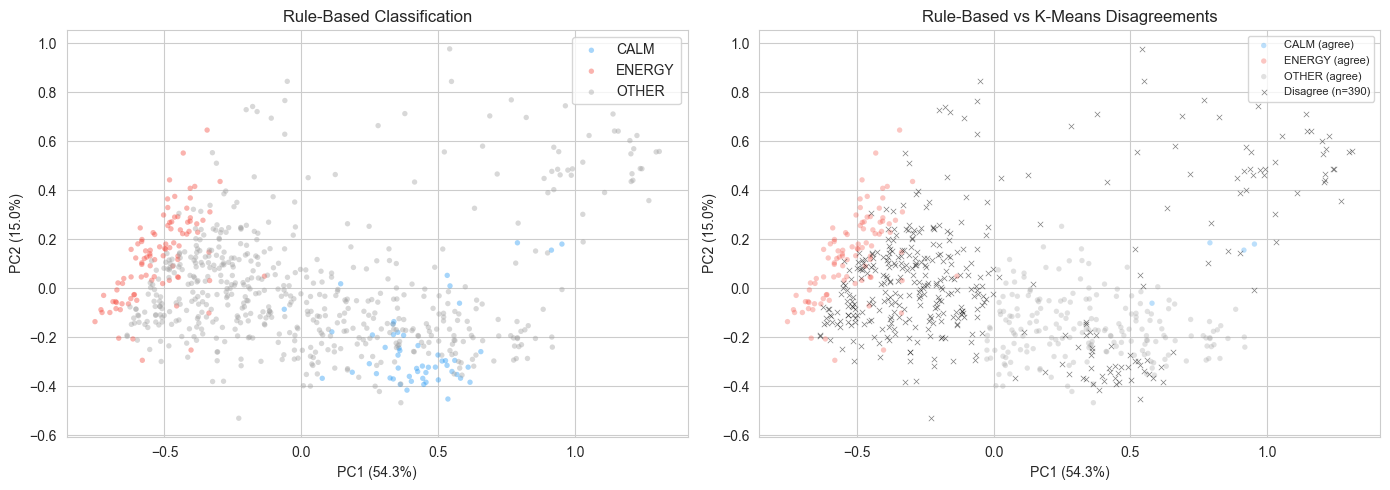


Disagreements: 390 / 691 songs (56.4%)


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  5d. VISUALIZE AGREEMENT — PCA scatter with disagreements highlighted
# ══════════════════════════════════════════════════════════════════════════════

CLASS_COLORS = {"calm": "#2196F3", "energy": "#F44336", "other": "#9E9E9E"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rule-based classification
for cls, color in CLASS_COLORS.items():
    mask = df["class"] == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=cls.upper(),
                    alpha=0.4, s=15, edgecolors="none")
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("Rule-Based Classification")
axes[0].legend()

# Right: Same but highlight K-Means disagreements with × markers
agree_mask = df["class"] == df["kmeans_label"]
# Plot agreements as dots
for cls, color in CLASS_COLORS.items():
    mask = (df["class"] == cls) & agree_mask
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=f"{cls.upper()} (agree)",
                    alpha=0.3, s=15, edgecolors="none")
# Plot disagreements as ×
disagree_mask = ~agree_mask
axes[1].scatter(X_pca[disagree_mask, 0], X_pca[disagree_mask, 1],
                c="black", marker="x", s=15, alpha=0.5, linewidths=0.5,
                label=f"Disagree (n={disagree_mask.sum()})")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title("Rule-Based vs K-Means Disagreements")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nDisagreements: {disagree_mask.sum()} / {len(df)} songs ({disagree_mask.mean()*100:.1f}%)")

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  5e. INSPECT DISAGREEMENTS — interesting edge cases
# ══════════════════════════════════════════════════════════════════════════════
# Look at tracks where rule-based and K-Means disagree to understand edge cases.

show_cols = ["name", "artists", "tempo", "energy", "valence", "loudness",
             "arousal_score", "class", "kmeans_label"]
show_cols = [c for c in show_cols if c in df.columns]

disagreed = df[~agree_mask]
if len(disagreed) > 0:
    print(f"Sample of disagreements ({min(15, len(disagreed))} of {len(disagreed)}):\n")
    display(disagreed[show_cols].sample(min(15, len(disagreed)), random_state=RANDOM_STATE))
else:
    print("Perfect agreement — no disagreements to inspect.")

Sample of disagreements (15 of 390):



,name,artists,tempo,energy,valence,loudness,arousal_score,class,kmeans_label
23,undressed,sombr,115.999,0.887,0.8880,-3.883,0.644848,other,energy
83,Reflections,Alex Baranowski;Jess Gillam;Jess Gillam Ensemble,66.670,0.126,0.0394,-11.993,0.100336,other,calm
71,Chandelier,Sia,117.089,0.787,0.5720,-2.880,0.616781,other,energy
574,Green & Gold,Lianne La Havas,93.966,0.400,0.2620,-8.458,0.385342,other,energy
523,Real Peach,Henry Jamison,151.985,0.559,0.3280,-7.338,0.538419,other,energy
675,Bruises,Lewis Capaldi,118.641,0.323,0.3570,-6.213,0.341609,calm,other
110,Collide,Howie Day,93.931,0.625,0.3420,-7.895,0.466969,other,energy
517,Numb / Encore,JAY-Z;Linkin Park,107.005,0.803,0.7990,-4.251,0.604609,other,energy
466,You Wouldn't Like Me,The Beths,147.648,0.572,0.6170,-8.114,0.564966,other,energy
193,Someone New,Hozier,183.810,0.533,0.5800,-5.955,0.590818,other,energy


---
## Phase 6 — Evaluation & Threshold Tuning
**Goal:** Validate the classification and optionally sweep thresholds to find optimal settings.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  6a. THRESHOLD SENSITIVITY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
# Sweep calm and energy thresholds to see how class sizes and silhouette change.
# This helps identify robust threshold regions (where small changes don't flip results).

calm_range = np.arange(0.25, 0.46, 0.05)
energy_range = np.arange(0.55, 0.76, 0.05)

results = []
for ct in calm_range:
    for et in energy_range:
        if ct >= et:
            continue  # thresholds must not overlap

        # Reclassify with these thresholds
        labels = []
        for arousal, val in zip(df["arousal_score"], df_scaled["valence"]):
            if arousal < ct and val >= VALENCE_FLOOR:
                labels.append("calm")
            elif arousal > et:
                labels.append("energy")
            else:
                labels.append("other")

        n_calm = labels.count("calm")
        n_energy = labels.count("energy")
        n_other = labels.count("other")

        # Silhouette score for this partitioning
        sil = silhouette_score(X_scaled, labels) if n_calm > 0 and n_energy > 0 else 0

        results.append({
            "calm_thresh": ct, "energy_thresh": et,
            "n_calm": n_calm, "n_energy": n_energy, "n_other": n_other,
            "pct_calm": n_calm / len(df) * 100,
            "pct_energy": n_energy / len(df) * 100,
            "silhouette": sil,
        })

sweep_df = pd.DataFrame(results).round(3)
print("Threshold sweep results (sorted by silhouette):")
display(sweep_df.sort_values("silhouette", ascending=False).head(10))

# Highlight current settings
current = sweep_df[
    (sweep_df["calm_thresh"] == CALM_THRESHOLD) &
    (sweep_df["energy_thresh"] == ENERGY_THRESHOLD)
]
if len(current) > 0:
    print(f"\nCurrent settings (calm={CALM_THRESHOLD}, energy={ENERGY_THRESHOLD}):")
    display(current)

Threshold sweep results (sorted by silhouette):


,calm_thresh,energy_thresh,n_calm,n_energy,n_other,pct_calm,pct_energy,silhouette
20,0.45,0.55,129,257,305,18.669,37.192,0.118
15,0.40,0.55,89,257,345,12.880,37.192,0.103
10,0.35,0.55,53,257,381,7.670,37.192,0.087
0,0.25,0.55,12,257,422,1.737,37.192,0.085
5,0.30,0.55,31,257,403,4.486,37.192,0.081
21,0.45,0.60,129,170,392,18.669,24.602,0.041
16,0.40,0.60,89,170,432,12.880,24.602,0.025
11,0.35,0.60,53,170,468,7.670,24.602,0.009
1,0.25,0.60,12,170,509,1.737,24.602,0.002
6,0.30,0.60,31,170,490,4.486,24.602,0.001



Current settings (calm=0.35, energy=0.65):


,calm_thresh,energy_thresh,n_calm,n_energy,n_other,pct_calm,pct_energy,silhouette
12,0.35,0.65,53,96,542,7.67,13.893,-0.044


Within-class statistics (mean ± std):
───────────────────────────────────────────────────────
    CALM (n=  53): tempo=103.0±18.5, energy=0.3±0.1
  ENERGY (n=  96): tempo=152.1±24.0, energy=0.9±0.1
   OTHER (n= 542): tempo=115.8±25.3, energy=0.5±0.2


/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_15499/1999415890.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=axes[i])
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_15499/1999415890.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=axes[i])


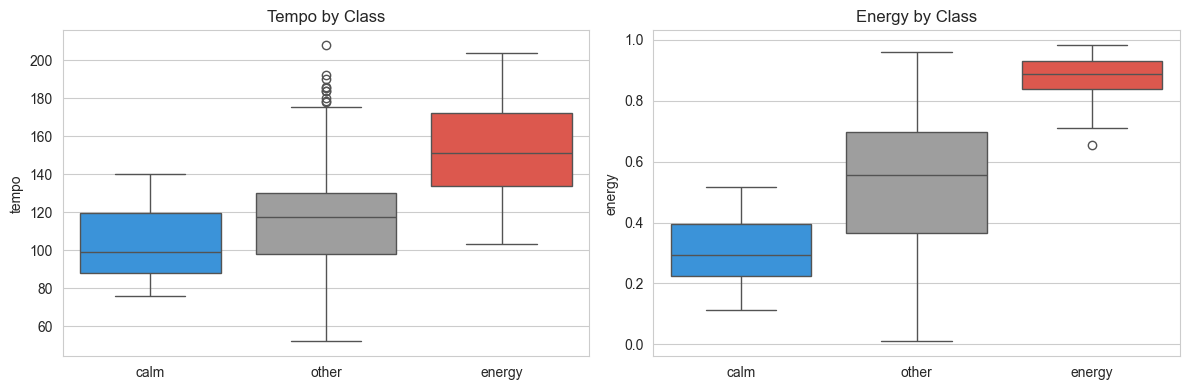

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  6b. WITHIN-CLASS COHERENCE & CROSS-CLASS SEPARATION
# ══════════════════════════════════════════════════════════════════════════════
# Good classification = low variance within classes, large gaps between classes.

key_features = ["tempo", "energy"]

print("Within-class statistics (mean ± std):")
print(f"{'─'*55}")
for cls in ["calm", "energy", "other"]:
    subset = df[df["class"] == cls]
    parts = []
    for feat in key_features:
        m = subset[feat].mean()
        s = subset[feat].std()
        parts.append(f"{feat}={m:.1f}±{s:.1f}")
    print(f"  {cls.upper():>6} (n={len(subset):>4}): {', '.join(parts)}")

# Boxplots for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ["calm", "other", "energy"]
palette = [CLASS_COLORS[c] for c in order]

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=axes[i])
    axes[i].set_title(f"{feat.title()} by Class")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  6c. MANUAL SPOT-CHECK — 10 random songs per class
# ══════════════════════════════════════════════════════════════════════════════
# The most important evaluation step: do these songs "feel right" for their class?

spot_cols = ["name", "artists", "tempo", "energy", "valence", "loudness", "arousal_score", "class"]
spot_cols = [c for c in spot_cols if c in df.columns]

for cls in ["calm", "energy", "other"]:
    subset = df[df["class"] == cls]
    n_show = min(10, len(subset))
    print(f"\n{'═'*70}")
    print(f"  {cls.upper()} — {n_show} random samples (of {len(subset)} total)")
    print(f"{'═'*70}")
    display(subset[spot_cols].sample(n_show, random_state=RANDOM_STATE))


══════════════════════════════════════════════════════════════════════
  CALM — 10 random samples (of 53 total)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,arousal_score,class
275,Over Jordan,Papa M,89.258,0.196,0.283,-15.491,0.165526,calm
603,Homesick,Dua Lipa,85.728,0.224,0.399,-8.683,0.215452,calm
663,When Will I Learn,Kina Grannis,129.650,0.278,0.374,-13.686,0.287989,calm
194,Jolene,Ray LaMontagne,119.656,0.142,0.288,-15.196,0.216724,calm
617,First Day Of My Life,Bright Eyes,95.345,0.201,0.385,-17.024,0.172010,calm
94,"Cello Suite No. 1 in G Major, BWV 1007: I. Pré...",Johann Sebastian Bach;Viviane Spanoghe,97.155,0.123,0.745,-26.413,0.050987,calm
225,Ho Hey,The Lumineers,79.907,0.471,0.421,-9.182,0.321989,calm
672,Liability,Lorde,76.715,0.218,0.345,-11.160,0.184774,calm
80,Ready or Not,Fugees;Ms. Lauryn Hill;Wyclef Jean;Pras,89.129,0.428,0.524,-13.392,0.334964,calm
424,No Right To Love You - Acoustic,Rhys Lewis,84.186,0.269,0.520,-10.600,0.227557,calm



══════════════════════════════════════════════════════════════════════
  ENERGY — 10 random samples (of 96 total)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,arousal_score,class
506,I Love It,Icona Pop;Charli xcx,125.953,0.901,0.860,-2.686,0.695573,energy
482,All at Once,The Fray,133.879,0.863,0.509,-2.509,0.685277,energy
469,Everything Is AWESOME!!! (feat. The Lonely Isl...,Tegan and Sara;The Lonely Island,147.999,0.960,0.738,-3.595,0.750909,energy
634,She Will Be Loved,Maroon 5,203.867,0.711,0.539,-5.494,0.738895,energy
220,Red Light Green Light,Used,171.958,0.809,0.359,-4.480,0.724593,energy
501,Meant to Be (feat. Florida Georgia Line),Bebe Rexha;Florida Georgia Line,154.084,0.783,0.579,-6.458,0.669103,energy
462,"Goodbye, Goodbye",Tegan and Sara,134.970,0.873,0.736,-5.581,0.676179,energy
331,Shut Up and Dance,WALK THE MOON,128.038,0.866,0.619,-3.804,0.670464,energy
7,That's Not My Name,The Ting Tings,145.042,0.901,0.959,-3.152,0.727453,energy
32,DARE (feat. Shaun Ryder & Roses Gabor),Gorillaz;Shaun Ryder;Roses Gabor,120.264,0.891,0.966,-5.852,0.656951,energy



══════════════════════════════════════════════════════════════════════
  OTHER — 10 random samples (of 542 total)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,arousal_score,class
466,You Wouldn't Like Me,The Beths,147.648,0.5720,0.6170,-8.114,0.564966,other
92,Pian Perduto,Olivia Belli;Louisa Fuller;John Metcalfe;Chris...,135.753,0.0268,0.0508,-24.540,0.096843,other
453,Ride,Lana Del Rey,93.763,0.6860,0.1890,-5.520,0.501914,other
113,Christine,Christine and the Queens,100.027,0.3640,0.4540,-10.322,0.377606,other
297,Secret - Acoustic,Angel Snow,112.580,0.2950,0.1450,-11.548,0.309071,other
100,Snowman,Sia,104.953,0.5240,0.3390,-6.222,0.449521,other
260,Escape,Hans Zimmer;Richard Harvey,143.778,0.3410,0.0403,-15.733,0.324043,other
646,Save Yourself,KALEO,120.436,0.3380,0.1110,-8.608,0.373359,other
683,Escape (The Pina Colada Song),Rupert Holmes,139.344,0.7390,0.9540,-7.198,0.610043,other
660,Bohemian Bird,Grizfolk,145.034,0.6370,0.1730,-8.081,0.575830,other


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  6d. COMPARISON WITH EXISTING RULE-BASED APPROACH
# ══════════════════════════════════════════════════════════════════════════════
# Compare with the thresholds from generate.py to see overlap.
# generate.py calm filter: tempo 50-70, energy <0.6, acousticness >0.3
# generate.py energy filter: tempo 120-150, energy >0.7, danceability >0.5, valence >0.5

# Classify using generate.py rules
def rule_based_class(row):
    """Mimic generate.py's filtering logic for comparison."""
    if (50 <= row["tempo"] <= 70 and row["energy"] < 0.6
            and row.get("acousticness", 0) > 0.3):
        return "calm"
    elif (120 <= row["tempo"] <= 150 and row["energy"] > 0.7
              and row.get("danceability", 0) > 0.5
              and row.get("valence", 0) > 0.5):
        return "energy"
    else:
        return "other"

df["rule_based_class"] = df.apply(rule_based_class, axis=1)

# Compare
rule_counts = df["rule_based_class"].value_counts()
print("generate.py rule-based classification:")
for cls in ["calm", "energy", "other"]:
    n = rule_counts.get(cls, 0)
    print(f"  {cls.upper():>6}: {n:>5} songs")

# Overlap with our arousal-based classification
print("\nOverlap: arousal-based (rows) vs generate.py rules (columns)")
ct_rules = pd.crosstab(df["class"], df["rule_based_class"], margins=True)
display(ct_rules)

# Clean up temporary column
df.drop(columns=["rule_based_class"], inplace=True)

generate.py rule-based classification:
    CALM:    11 songs
  ENERGY:    48 songs
   OTHER:   632 songs

Overlap: arousal-based (rows) vs generate.py rules (columns)


rule_based_class,calm,energy,other,All
class,,,,
calm,0,0,53,53
energy,0,20,76,96
other,11,28,503,542
All,11,48,632,691


---
## Phase 7 — Integration & Output
**Goal:** Save annotated CSV, visualizations, and pipeline artifacts.

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  7a. SAVE ANNOTATED CSV
# ══════════════════════════════════════════════════════════════════════════════
# Output: original columns + "class" + "arousal_score" columns.
# Drops internal columns (kmeans_cluster, gmm_cluster, etc.) to keep it clean.

output_dir = PROJECT_ROOT / "data" / "playlists" / PARTICIPANT / "playlist_ml"
output_dir.mkdir(parents=True, exist_ok=True)

# Select columns to save: original columns + classification results
internal_cols = {"kmeans_cluster", "kmeans_label", "gmm_cluster", "gmm_label", "gmm_confidence"}
save_cols = [c for c in df.columns if c not in internal_cols]
df_output = df[save_cols].copy()

csv_path = output_dir / "classified_songs.csv"
df_output.to_csv(csv_path, index=False)

print(f"✓ Saved annotated CSV: {csv_path}")
print(f"  {len(df_output)} songs, columns: {list(df_output.columns[-3:])}")
print(f"\n  Class distribution in output:")
for cls in ["calm", "energy", "other"]:
    n = (df_output["class"] == cls).sum()
    print(f"    {cls.upper():>6}: {n:>5} songs")

✓ Saved annotated CSV: /Users/timothydhoe/Code/spotify-project/data/playlists/peer/playlist_ml/classified_songs.csv
  691 songs, columns: ['participant', 'arousal_score', 'class']

  Class distribution in output:
      CALM:    53 songs
    ENERGY:    96 songs
     OTHER:   542 songs


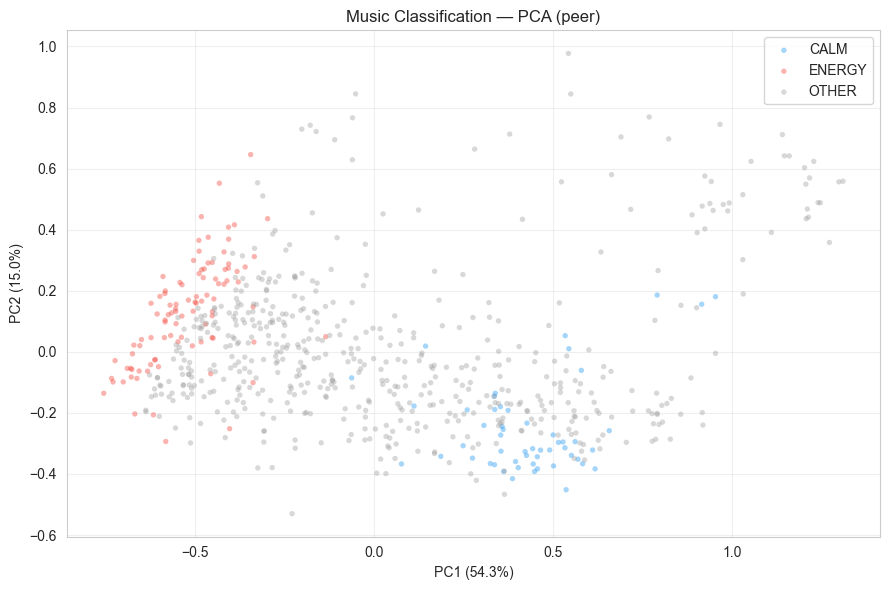

✓ Saved PCA plot


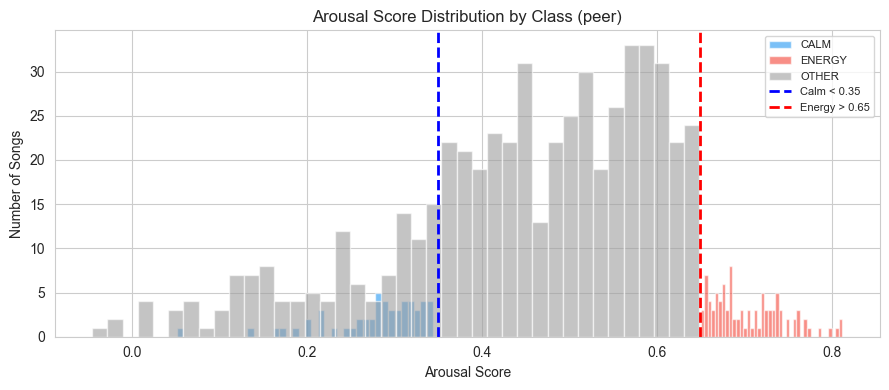

✓ Saved arousal distribution plot


/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_15499/1247485093.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=ax)
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_15499/1247485093.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=ax)
/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_15499/1247485093.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=feat, or

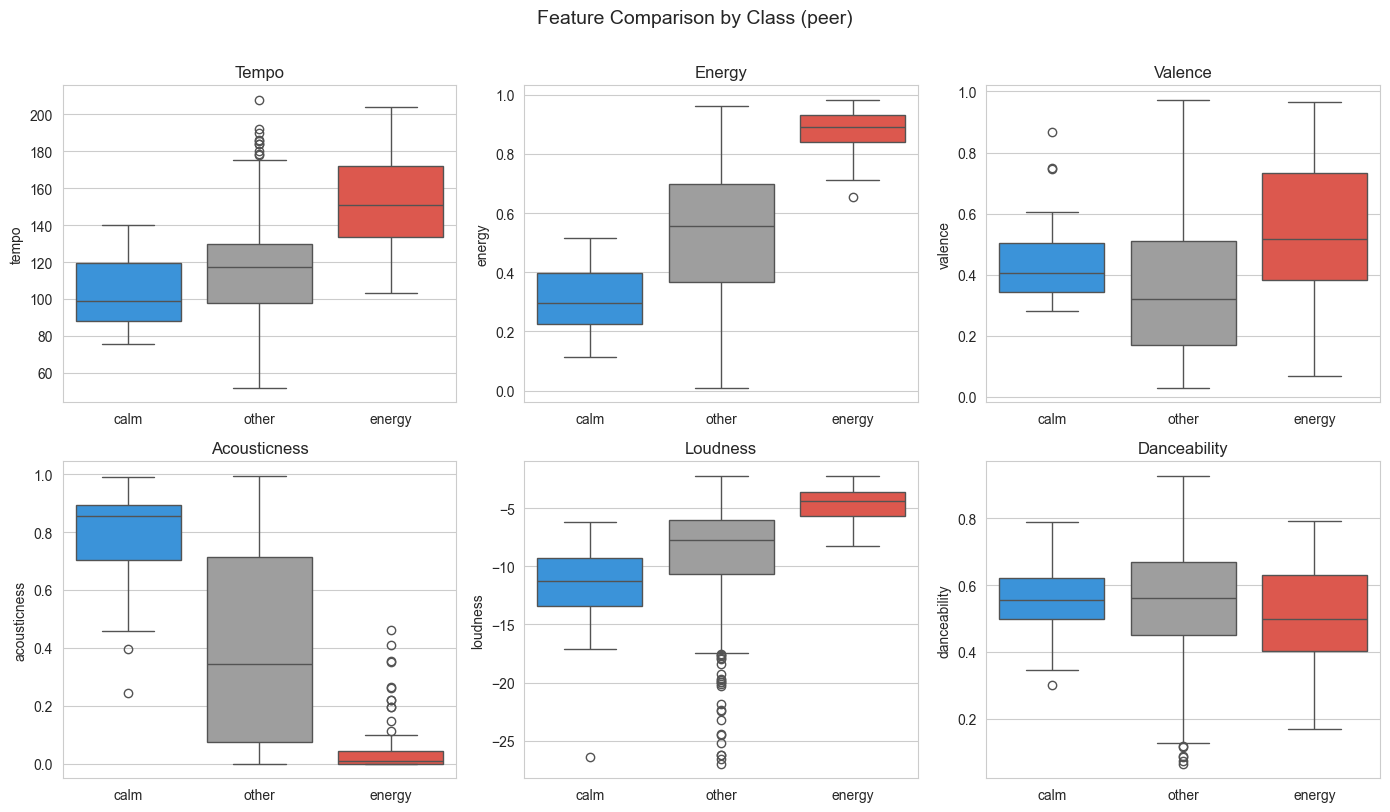

✓ Saved feature boxplots


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  7b. SAVE VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

# --- Plot 1: PCA scatter colored by class ---
fig, ax = plt.subplots(figsize=(9, 6))
for cls, color in CLASS_COLORS.items():
    mask = df["class"] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=cls.upper(),
               alpha=0.4, s=15, edgecolors="none")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_title(f"Music Classification — PCA ({PARTICIPANT})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(output_dir / f"{PARTICIPANT}_pca_classes.jpg", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved PCA plot")

# --- Plot 2: Arousal score distribution with thresholds ---
fig, ax = plt.subplots(figsize=(9, 4))
for cls, color in CLASS_COLORS.items():
    subset = df[df["class"] == cls]["arousal_score"]
    ax.hist(subset, bins=40, color=color, alpha=0.6, label=cls.upper(), edgecolor="white")
ax.axvline(CALM_THRESHOLD, color="blue", linestyle="--", linewidth=2, label=f"Calm < {CALM_THRESHOLD}")
ax.axvline(ENERGY_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Energy > {ENERGY_THRESHOLD}")
ax.set_xlabel("Arousal Score")
ax.set_ylabel("Number of Songs")
ax.set_title(f"Arousal Score Distribution by Class ({PARTICIPANT})")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(output_dir / f"{PARTICIPANT}_arousal_distribution.jpg", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved arousal distribution plot")

# --- Plot 3: Feature comparison boxplots ---
plot_features = ["tempo", "energy", "valence", "acousticness", "loudness", "danceability"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
order = ["calm", "other", "energy"]
palette = [CLASS_COLORS[c] for c in order]

for idx, feat in enumerate(plot_features):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x="class", y=feat, order=order, palette=palette, ax=ax)
    ax.set_title(feat.title())
    ax.set_xlabel("")

fig.suptitle(f"Feature Comparison by Class ({PARTICIPANT})", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(output_dir / f"{PARTICIPANT}_feature_boxplots.jpg", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved feature boxplots")

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
#  7c. SAVE PIPELINE ARTIFACTS
# ══════════════════════════════════════════════════════════════════════════════
# Save the scaler and configuration so the pipeline can be rerun consistently.

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# 1. Save fitted MinMaxScaler
scaler_path = models_dir / "scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✓ Saved scaler: {scaler_path}")

# 2. Save pipeline configuration as JSON
config = {
    "created": datetime.now().isoformat(),
    "participant": PARTICIPANT,
    "n_songs_total": len(df_raw),
    "n_songs_after_filter": len(df),
    "scoring_features": SCORING_FEATURES,
    "arousal_weights": AROUSAL_WEIGHTS,
    "thresholds": {
        "calm": CALM_THRESHOLD,
        "energy": ENERGY_THRESHOLD,
        "valence_floor": VALENCE_FLOOR,
    },
    "pre_filters": {
        "speechiness_max": SPEECHINESS_THRESHOLD,
        "liveness_max": LIVENESS_THRESHOLD,
    },
    "class_distribution": {
        cls: int((df["class"] == cls).sum()) for cls in ["calm", "energy", "other"]
    },
    "silhouette_score": float(sil_rules),
}

config_path = models_dir / "config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"✓ Saved config: {config_path}")

✓ Saved scaler: /Users/timothydhoe/Code/spotify-project/models/scaler.pkl
✓ Saved config: /Users/timothydhoe/Code/spotify-project/models/config.json


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
#  7d. GENERATE SUMMARY REPORT
# ══════════════════════════════════════════════════════════════════════════════

report_lines = [
    f"Music Classification Report - {PARTICIPANT}",
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"{'='*60}",
    f"",
    f"DATA",
    f"  Total songs loaded:        {len(df_raw)}",
    f"  After dedup + NaN removal: {len(df) + n_removed + n_dupes}",
    f"  Excluded (speech/live):    {n_removed}",
    f"  Songs classified:          {len(df)}",
    f"",
    f"AROUSAL SCORE FORMULA",
    f"  arousal = " + " + ".join(
        f"{w:+.2f}*{f}" for f, w in AROUSAL_WEIGHTS.items()
    ),
    f"  (computed on MinMax-scaled [0,1] features)",
    f"",
    f"CLASSIFICATION THRESHOLDS",
    f"  CALM:   arousal < {CALM_THRESHOLD} AND valence >= {VALENCE_FLOOR}",
    f"  ENERGY: arousal > {ENERGY_THRESHOLD}",
    f"  OTHER:  everything else",
    f"",
    f"CLASS DISTRIBUTION",
]

for cls in ["calm", "energy", "other"]:
    n = (df["class"] == cls).sum()
    pct = n / len(df) * 100
    report_lines.append(f"  {cls.upper():>6}: {n:>5} songs ({pct:.1f}%)")

report_lines += [
    f"",
    f"MEAN FEATURES PER CLASS",
    class_means.to_string(),
    f"",
    f"VALIDATION",
    f"  Silhouette score (rule-based): {sil_rules:.3f}",
    f"  K-Means agreement:             {agree_kmeans:.1%}",
    f"  GMM agreement:                 {agree_gmm:.1%}",
    f"  Note: Low agreement expected (OTHER is a catch-all, overlaps in feature space)",
    f"",
    f"PRE-FILTER THRESHOLDS",
    f"  Speechiness > {SPEECHINESS_THRESHOLD} excluded: {n_speech}",
    f"  Liveness > {LIVENESS_THRESHOLD} excluded:    {n_live}",
]

report_text = "\n".join(report_lines)
report_path = output_dir / f"{PARTICIPANT}_classification_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Saved report: {report_path}")
print(f"\n{'─'*60}")
print(report_text)

Saved report: /Users/timothydhoe/Code/spotify-project/data/playlists/peer/playlist_ml/peer_classification_report.txt

────────────────────────────────────────────────────────────
Music Classification Report - peer
Generated: 2026-04-02 11:09

DATA
  Total songs loaded:        691
  After dedup + NaN removal: 691
  Excluded (speech/live):    0
  Songs classified:          691

AROUSAL SCORE FORMULA
  arousal = +0.35*energy + +0.30*tempo + +0.20*loudness + -0.10*acousticness + +0.05*danceability
  (computed on MinMax-scaled [0,1] features)

CLASSIFICATION THRESHOLDS
  CALM:   arousal < 0.35 AND valence >= 0.25
  ENERGY: arousal > 0.65
  OTHER:  everything else

CLASS DISTRIBUTION
    CALM:    53 songs (7.7%)
  ENERGY:    96 songs (13.9%)
   OTHER:   542 songs (78.4%)

MEAN FEATURES PER CLASS
          tempo  energy  loudness  valence  danceability  acousticness  instrumentalness  speechiness  arousal_score
class                                                                             

---
## Phase 8 — Retraining / Maintenance

### How to retrain for a new participant:
1. Change `PARTICIPANT` in the Configuration cell (Phase 1)
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`)
3. Check the class distribution (Phase 4b) — if CALM or ENERGY < 5%, adjust thresholds
4. Spot-check 10 songs per class (Phase 6c) — do they "feel right"?
5. Outputs are auto-saved to `data/playlists/{participant}/playlist_ml/`

### What changes on retrain:
- **MinMaxScaler** refits to the new participant's data range
- **Arousal scores** recompute based on new scaling
- **Thresholds stay fixed** — they are domain-driven, not data-driven
- **K-Means / GMM** refit as independent validation

### What to watch for:
- Class distribution shifts dramatically → inspect data, maybe different music taste
- Silhouette score drops below 0.15 → classes not well-separated in this data
- Spot-check reveals misclassifications → consider adjusting weights or thresholds

### Multi-participant mode:
Set `PARTICIPANT = "all"` to classify across all participants at once.

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
#  DONE — Pipeline complete
# ══════════════════════════════════════════════════════════════════════════════

print(f"Pipeline complete for participant: {PARTICIPANT}")
print(f"{'─'*50}")
print(f"  Songs classified: {len(df)}")
print(f"  Output CSV:       {csv_path}")
print(f"  Report:           {report_path}")
print(f"  Scaler:           {scaler_path}")
print(f"  Config:           {config_path}")
print(f"{'─'*50}")
print(f"  CALM:   {(df['class'] == 'calm').sum():>5} songs")
print(f"  ENERGY: {(df['class'] == 'energy').sum():>5} songs")
print(f"  OTHER:  {(df['class'] == 'other').sum():>5} songs")

Pipeline complete for participant: peer
──────────────────────────────────────────────────
  Songs classified: 691
  Output CSV:       /Users/timothydhoe/Code/spotify-project/data/playlists/peer/playlist_ml/classified_songs.csv
  Report:           /Users/timothydhoe/Code/spotify-project/data/playlists/peer/playlist_ml/peer_classification_report.txt
  Scaler:           /Users/timothydhoe/Code/spotify-project/models/scaler.pkl
  Config:           /Users/timothydhoe/Code/spotify-project/models/config.json
──────────────────────────────────────────────────
  CALM:      53 songs
  ENERGY:    96 songs
  OTHER:    542 songs
